In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
sys.path.append('./tools')

import plot_from_log as pfl

In [142]:
'''
Comments for each of the files:

0, data_20260519_203733: inlet_choked,yes
1, data_20260519_204401: inlet_choked,yes
2, data_20260519_204443: inlet_choked,yes - showing that 13% speed at compressor is not enough to overcome chamber pressure backflow
3, data_20260519_205158: inlet_choked,no - checking at which minimum duty cycle the compressor can maintain adequate pressure
4, data_20260519_210630: inlet_choked,yes - showing that we can't pressurize the chamber with a choked inlet even if the piston is full power
5, data_20260519_213040: inlet_choked,no
6, data_20260606_194117: inlet_choked,only_compressor_manual_outlet
7, data_20260606_200711: inlet_choked,flow_rate_dpump_pressurising
8, data_20260606_201104: inlet_choked,ppump_only_choked_outlet
9, data_20260606_202038: inlet_choked,dpump_only_choked_inlet_the_betterOne
10, data_20260606_202452: inlet_choked,dpump_only_choked_inlet_the_betterOne
11, data_20260606_204601: inlet_choked,full_system_choked_inlet_TheBetterOne_manualOutlet
12, data_20260606_205954: inlet_choked,dpump_only_choked_inlet_TheBetterOne_chokedOutlet
13, data_20260606_210134: inlet_choked,dpump_only_choked_inlet_TheWorseOne_chokedOutlet
'''


paths = [
    r'.\logs\data_20260519_203733.csv',
    r'.\logs\data_20260519_204401.csv',
    r'.\logs\data_20260519_204443.csv',
    r'.\logs\data_20260519_205158.csv',
    r'.\logs\data_20260519_210630.csv',
    r'.\logs\data_20260519_213040.csv',
    r'.\logs\data_20260606_194117.csv',
    r'.\logs\data_20260606_200711.csv',
    r'.\logs\data_20260606_201104.csv',
    r'.\logs\data_20260606_202038.csv',
    r'.\logs\data_20260606_202452.csv',
    r'.\logs\data_20260606_204601.csv',
    r'.\logs\data_20260606_205954.csv',
    r'.\logs\data_20260606_210134.csv'
]

p1 = paths[11]
p2 = paths[12]
p3 = paths[6] #4

In [143]:
df1 = pd.read_csv(p1, skiprows=1, usecols=[1,2,3,4,5,6])
df2 = pd.read_csv(p2, skiprows=1, usecols=[1,2,3,4,5,6])
df3 = pd.read_csv(p3, skiprows=1, usecols=[1,2,3,4,5,6])
df2.head(30)

,ts_ms,diaphragm_pct,piston_pct,mpx_pressure_hPa,bmp_temp_C,bmp_pressure_hPa
0,1130,0,0,-15.86,22.93,1011.35
1,2023,0,0,-15.86,22.93,1011.32
2,3022,0,0,-15.86,22.93,1011.28
3,4023,0,0,-15.86,22.93,1011.21
4,5022,0,0,-15.86,22.93,1011.20
5,6023,0,0,-15.86,22.93,1011.17
6,7022,0,0,-15.86,22.93,1011.10
7,8023,0,0,-15.86,22.93,1011.10
8,9023,0,0,-15.86,22.93,1011.08
9,10022,0,0,-15.86,22.93,1011.08


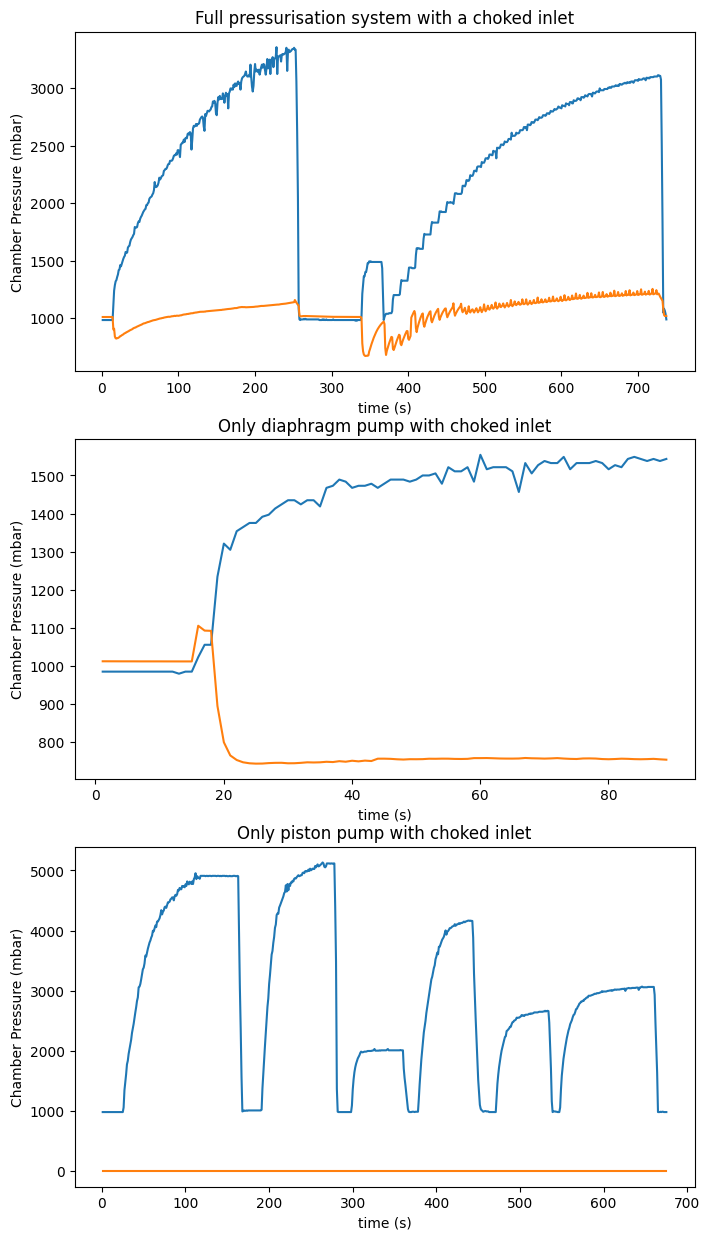

In [144]:
fig,axes = plt.subplots(3,1, figsize=(8,15))

axes[0].set_title('Full pressurisation system with a choked inlet')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('Chamber Pressure (mbar)')
axes[0].plot(df1.ts_ms/1000, df1.mpx_pressure_hPa+1000)
axes[0].plot(df1.ts_ms/1000, df1.bmp_pressure_hPa)

axes[1].set_title('Only diaphragm pump with choked inlet')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('Chamber Pressure (mbar)')
axes[1].plot(df2.ts_ms/1000, df2.mpx_pressure_hPa+1000)
axes[1].plot(df2.ts_ms/1000, df2.bmp_pressure_hPa)

axes[2].set_title('Only piston pump with choked inlet')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('Chamber Pressure (mbar)')
axes[2].plot(df3.ts_ms/1000, df3.mpx_pressure_hPa+1000)
axes[2].plot(df3.ts_ms/1000, df3.bmp_pressure_hPa)

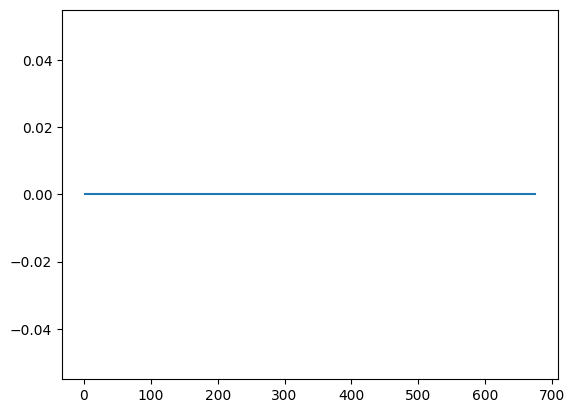

In [145]:
plt.plot(df3.ts_ms/1000, df3.bmp_pressure_hPa)

Text(0, 0.5, 'Duty cycle (%)')

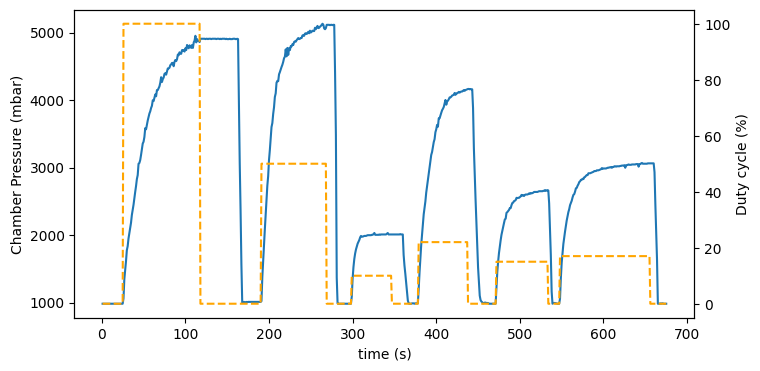

In [146]:
fig, axes = plt.subplots(1,1,figsize=(8,4))
p1 = axes.plot(df3.ts_ms/1000, df3.mpx_pressure_hPa+1000)
axes.set_ylabel('Chamber Pressure (mbar)')
axes.set_xlabel('time (s)')
ax2 = axes.twinx()

p2 = ax2.plot(df3.ts_ms/1000,df3.piston_pct, color='orange', linestyle='dashed')
ax2.set_ylabel('Duty cycle (%)')

In [149]:
df3.loc[np.abs(df3.mpx_pressure_hPa-2000)<20]

,ts_ms,diaphragm_pct,piston_pct,mpx_pressure_hPa,bmp_temp_C,bmp_pressure_hPa
391,392019,0,22,1988.05,0.0,0.0
597,598020,0,17,1993.48,0.0,0.0
598,599019,0,17,1982.62,0.0,0.0
599,600019,0,17,1988.05,0.0,0.0
600,601020,0,17,1988.05,0.0,0.0
601,602019,0,17,1988.05,0.0,0.0
602,603020,0,17,1988.05,0.0,0.0
603,604019,0,17,1993.48,0.0,0.0
604,605020,0,17,1998.91,0.0,0.0
605,606019,0,17,1998.91,0.0,0.0


In [150]:
df3.iloc[391]

ts_ms               392019.00
diaphragm_pct            0.00
piston_pct              22.00
mpx_pressure_hPa      1988.05
bmp_temp_C               0.00
bmp_pressure_hPa         0.00
Name: 391, dtype: float64